# Comparative Analysis: BERT vs FinBERT vs GPT-OSS 20B

Three-model sentiment comparison on financial news headlines (CN7050 dataset).
- **BERT** — fine-tuned `bert-base-uncased`
- **FinBERT** — fine-tuned `ProsusAI/finbert`
- **GPT-OSS 20B** — prompted via Ollama (best prompt: P3_Hybrid_Master)

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                            recall_score, classification_report, confusion_matrix)
from sklearn.model_selection import train_test_split
from transformers import pipeline
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings("ignore")

# ── Load GPT-OSS results (source of truth for test texts) ──
gpt_df = pd.read_csv('./resources/gpt_oss_results.csv')
print(f"Loaded {len(gpt_df)} test samples from gpt_oss_results.csv")

# ── Data leakage check ──
# Verify these texts come from the random_state=13 test split (same as BERT training)
data = pd.read_csv("resources/cn7050data.csv", encoding='latin-1', names=["sentiment", "text"])
data = data.drop_duplicates().reset_index(drop=True).dropna()
data['sentiment'] = data['sentiment'].str.lower()

train_df_check, temp_check = train_test_split(data, test_size=0.20, random_state=13, stratify=data['sentiment'])
_, test_df_check = train_test_split(temp_check, test_size=0.50, random_state=13, stratify=temp_check['sentiment'])

train_texts = set(train_df_check['text'].tolist())
test_texts  = set(test_df_check['text'].tolist())
gpt_texts   = set(gpt_df['text'].tolist())

leakage = gpt_texts & train_texts
in_test = gpt_texts & test_texts

print(f"\nData Leakage Check:")
print(f"  GPT texts in BERT TRAINING set: {len(leakage)}/80")
print(f"  GPT texts in BERT TEST set:     {len(in_test)}/80")
if len(leakage) > 0:
    print(f"  ⚠️  WARNING: {len(leakage)} GPT samples overlap with BERT training data!")
    print(f"  → Re-run gptoss.ipynb (now fixed to random_state=13) to eliminate leakage.")
else:
    print(f"  ✅ No data leakage. All GPT test samples are outside BERT's training set.")

Loaded 80 test samples from gpt_oss_results.csv

Data Leakage Check:
  GPT texts in BERT TRAINING set: 0/80
  GPT texts in BERT TEST set:     77/80
  ✅ No data leakage. All GPT test samples are outside BERT's training set.


In [13]:
# ── Load fine-tuned models ──
print("Loading fine-tuned BERT and FinBERT pipelines...")
pipe_bert    = pipeline("text-classification",
                        model="./fine_tuned_bert-base-uncased",
                        tokenizer="./fine_tuned_bert-base-uncased")
pipe_finbert = pipeline("text-classification",
                        model="./fine_tuned_ProsusAI_finbert",
                        tokenizer="./fine_tuned_ProsusAI_finbert")

# ── Run inference on the exact same 80 texts ──
print("Running BERT and FinBERT inference on the 80 GPT test samples...")
bert_preds = []
finbert_preds = []

for text in tqdm(gpt_df['text'], leave=False):
    b = pipe_bert(text, truncation=True, max_length=512)[0]['label'].lower()
    f = pipe_finbert(text, truncation=True, max_length=512)[0]['label'].lower()
    bert_preds.append(b)
    finbert_preds.append(f)

# Build unified comparison dataframe
master_df = gpt_df[['text', 'true_label']].copy()
master_df['bert_pred']    = bert_preds
master_df['finbert_pred'] = finbert_preds
master_df['gpt_oss_pred'] = gpt_df['P3_Hybrid_Master_pred'].str.strip().str.lower()

# Normalize all label columns
for col in ['bert_pred', 'finbert_pred', 'gpt_oss_pred', 'true_label']:
    master_df[col] = master_df[col].str.strip().str.lower()

master_df.to_csv('./resources/final_all_models_comparison.csv', index=False)
print(f"✅ Saved unified comparison ({len(master_df)} rows) → final_all_models_comparison.csv")
master_df.head()

Loading fine-tuned BERT and FinBERT pipelines...


Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.
Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


Running BERT and FinBERT inference on the 80 GPT test samples...


  0%|          | 0/80 [00:00<?, ?it/s]

✅ Saved unified comparison (80 rows) → final_all_models_comparison.csv


,text,true_label,bert_pred,finbert_pred,gpt_oss_pred
0,"The planned facility , estimated to cost aroun...",positive,neutral,neutral,neutral
1,The amending of the proposal simplifies the pr...,positive,positive,positive,neutral
2,Return on capital employed rose by 4.8 percent...,positive,positive,positive,positive
3,The deal is in line with Etteplan 's strategy ...,neutral,positive,positive,neutral
4,The latest result included per-share charges o...,neutral,neutral,neutral,negative


In [14]:
# ── Compute per-model metrics ──
LABELS = ['negative', 'neutral', 'positive']
true = master_df['true_label']

models = {
    "BERT (fine-tuned)":    master_df['bert_pred'],
    "FinBERT (fine-tuned)": master_df['finbert_pred'],
    "GPT-OSS 20B":          master_df['gpt_oss_pred']
}

rows = []
for name, preds in models.items():
    rows.append({
        "Model": name,
        "Accuracy":        round(accuracy_score(true, preds), 4),
        "Macro-F1":        round(f1_score(true, preds, average='macro', labels=LABELS, zero_division=0), 4),
        "Macro-Precision": round(precision_score(true, preds, average='macro', labels=LABELS, zero_division=0), 4),
        "Macro-Recall":    round(recall_score(true, preds, average='macro', labels=LABELS, zero_division=0), 4),
    })

results_df = pd.DataFrame(rows)
print("=== Model Comparison ===")
print(results_df.to_string(index=False))

# Per-class classification reports
for name, preds in models.items():
    print(f"\n--- {name} ---")
    print(classification_report(true, preds, labels=LABELS, target_names=LABELS, zero_division=0))

=== Model Comparison ===
               Model  Accuracy  Macro-F1  Macro-Precision  Macro-Recall
   BERT (fine-tuned)     0.825    0.8042           0.7941        0.8156
FinBERT (fine-tuned)     0.850    0.8241           0.8555        0.8033
         GPT-OSS 20B     0.750    0.7246           0.7249        0.7279

--- BERT (fine-tuned) ---
              precision    recall  f1-score   support

    negative       0.86      0.92      0.89        13
     neutral       0.89      0.86      0.88        49
    positive       0.63      0.67      0.65        18

    accuracy                           0.82        80
   macro avg       0.79      0.82      0.80        80
weighted avg       0.83      0.82      0.83        80


--- FinBERT (fine-tuned) ---
              precision    recall  f1-score   support

    negative       1.00      0.77      0.87        13
     neutral       0.88      0.92      0.90        49
    positive       0.68      0.72      0.70        18

    accuracy                   

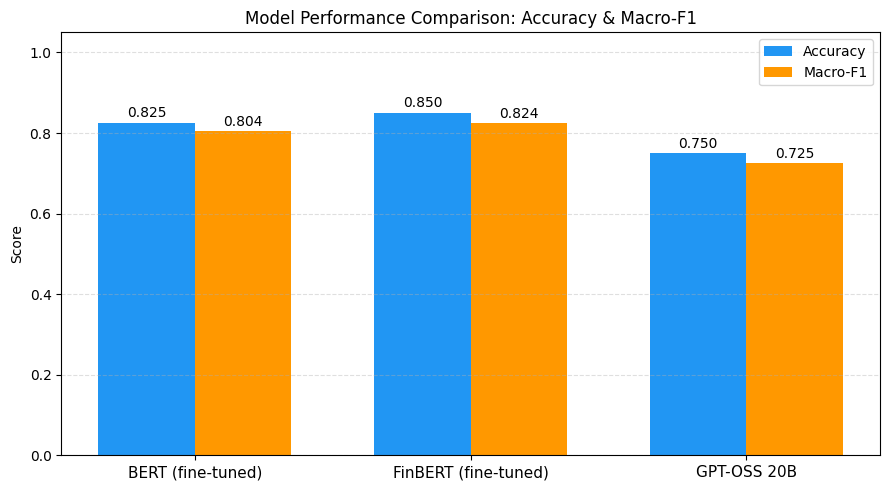

In [15]:
# ── Bar Chart: Accuracy and Macro-F1 ──
fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(results_df))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], results_df['Accuracy'],  width, label='Accuracy',  color='#2196F3')
bars2 = ax.bar([i + width/2 for i in x], results_df['Macro-F1'], width, label='Macro-F1', color='#FF9800')

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 4), textcoords="offset points", ha='center', fontsize=10)

ax.set_xticks(list(x))
ax.set_xticklabels(results_df['Model'], fontsize=11)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison: Accuracy & Macro-F1')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

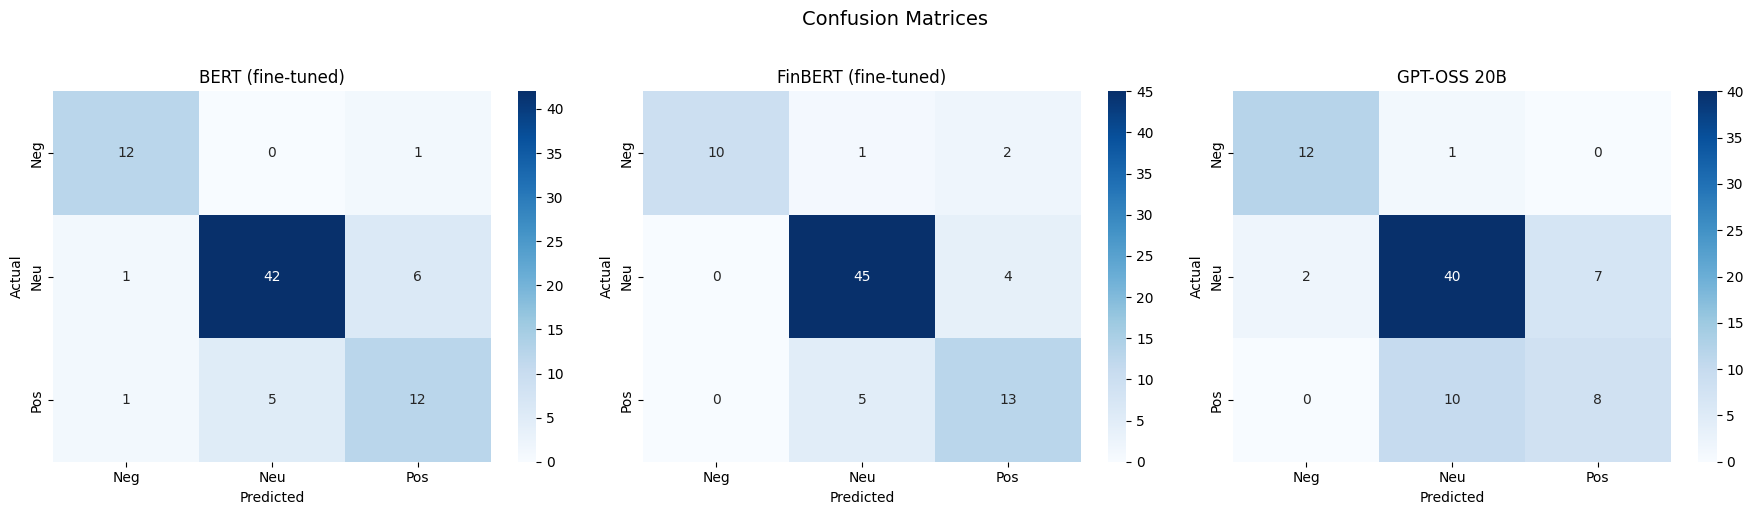

In [16]:
# ── Confusion Matrices (side-by-side) ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, preds) in zip(axes, models.items()):
    cm = confusion_matrix(true, preds, labels=LABELS)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Neg', 'Neu', 'Pos'],
                yticklabels=['Neg', 'Neu', 'Pos'])
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [19]:
## Qualitative Analysis
#Examining specific examples where models disagree to understand their strengths and failure modes.

In [20]:
# ── Cases where FinBERT is correct but BERT is wrong ──
finbert_wins = master_df[
    (master_df['finbert_pred'] == master_df['true_label']) &
    (master_df['bert_pred']    != master_df['true_label'])
].copy()

print(f"FinBERT correct but BERT wrong: {len(finbert_wins)} examples\n")
for _, row in finbert_wins.head(7).iterrows():
    print(f"  Text:    {row['text'][:120]}")
    print(f"  True:    {row['true_label']}")
    print(f"  BERT:    {row['bert_pred']}  ❌")
    print(f"  FinBERT: {row['finbert_pred']}  ✅")
    print()

# ── Cases where BERT is correct but FinBERT is wrong ──
bert_wins = master_df[
    (master_df['bert_pred']    == master_df['true_label']) &
    (master_df['finbert_pred'] != master_df['true_label'])
].copy()

print(f"\nBERT correct but FinBERT wrong: {len(bert_wins)} examples\n")
for _, row in bert_wins.head(5).iterrows():
    print(f"  Text:    {row['text'][:120]}")
    print(f"  True:    {row['true_label']}")
    print(f"  BERT:    {row['bert_pred']}  ✅")
    print(f"  FinBERT: {row['finbert_pred']}  ❌")
    print()

FinBERT correct but BERT wrong: 4 examples

  Text:    The permanent magnet generators and power converters are today the preferred solution in new wind turbine designs , the 
  True:    neutral
  BERT:    positive  ❌
  FinBERT: neutral  ✅

  Text:    26 November 2010 - Finnish sports-equipment maker Amer Sports Oyj ( HEL : AMEAS ) said today it has obtained a EUR30m Sc
  True:    neutral
  BERT:    positive  ❌
  FinBERT: neutral  ✅

  Text:    The manager is critical of politicians ' failure to differentiate between beleaguered European financial institutions an
  True:    neutral
  BERT:    negative  ❌
  FinBERT: neutral  ✅

  Text:    Nokia also noted the average selling price of handsets declined during the period , though its mobile phone profit margi
  True:    positive
  BERT:    negative  ❌
  FinBERT: positive  ✅


BERT correct but FinBERT wrong: 2 examples

  Text:    Cencorp 's net sales in the first quarter is estimated to be EUR0.9-1 .2 m , as compared to EUR4 .5 m in the f

In [21]:
# ── Cases where BOTH BERT and FinBERT are wrong ──
both_wrong = master_df[
    (master_df['bert_pred']    != master_df['true_label']) &
    (master_df['finbert_pred'] != master_df['true_label'])
].copy()

print(f"Both BERT and FinBERT wrong: {len(both_wrong)} examples\n")
for _, row in both_wrong.head(7).iterrows():
    print(f"  Text:    {row['text'][:120]}")
    print(f"  True:    {row['true_label']}")
    print(f"  BERT:    {row['bert_pred']}  ❌")
    print(f"  FinBERT: {row['finbert_pred']}  ❌")
    print(f"  GPT-OSS: {row['gpt_oss_pred']}  {'✅' if row['gpt_oss_pred'] == row['true_label'] else '❌'}")
    print()

Both BERT and FinBERT wrong: 10 examples

  Text:    The planned facility , estimated to cost around $ 814 million , would be the largest biodiesel plant in the world , and 
  True:    positive
  BERT:    neutral  ❌
  FinBERT: neutral  ❌
  GPT-OSS: neutral  ❌

  Text:    The deal is in line with Etteplan 's strategy to operate as a partner of global customers and provide industrial technol
  True:    neutral
  BERT:    positive  ❌
  FinBERT: positive  ❌
  GPT-OSS: neutral  ✅

  Text:    In 2007 , Marimekko has also opened concept stores in Yokohama and Nagoya , central Japan , in Silver Spring in metropol
  True:    positive
  BERT:    neutral  ❌
  FinBERT: neutral  ❌
  GPT-OSS: neutral  ❌

  Text:    Ingen is an established medical device manufacturer with an emerging new medical product line for the respiratory market
  True:    neutral
  BERT:    positive  ❌
  FinBERT: positive  ❌
  GPT-OSS: positive  ❌

  Text:    This rating from A.M. Best is the highest among the CIS countries , 

In [22]:
# ── GPT-OSS Reasoning Examples ──
# Pull in GPT-OSS explanations from the results CSV
gpt_full = pd.read_csv('./resources/gpt_oss_results.csv')
reasoning_df = master_df.merge(
    gpt_full[['text', 'P3_Hybrid_Master_exp']], on='text', how='left'
)

gpt_correct = reasoning_df[reasoning_df['gpt_oss_pred'] == reasoning_df['true_label']]
gpt_wrong   = reasoning_df[reasoning_df['gpt_oss_pred'] != reasoning_df['true_label']]

print(f"=== GPT-OSS Correct Examples ({len(gpt_correct)}/{len(reasoning_df)}) ===\n")
for _, row in gpt_correct.head(5).iterrows():
    print(f"  Text:      {row['text'][:100]}")
    print(f"  True:      {row['true_label']}")
    print(f"  GPT pred:  {row['gpt_oss_pred']}  ✅")
    print(f"  Reasoning: {row['P3_Hybrid_Master_exp']}")
    print()

print(f"\n=== GPT-OSS Wrong Examples ({len(gpt_wrong)}/{len(reasoning_df)}) ===\n")
for _, row in gpt_wrong.head(5).iterrows():
    print(f"  Text:      {row['text'][:100]}")
    print(f"  True:      {row['true_label']}")
    print(f"  GPT pred:  {row['gpt_oss_pred']}  ❌")
    print(f"  Reasoning: {row['P3_Hybrid_Master_exp']}")
    print()

=== GPT-OSS Correct Examples (60/80) ===

  Text:      Return on capital employed rose by 4.8 percentage points to 19.6 % .
  True:      positive
  GPT pred:  positive  ✅
  Reasoning: Return on capital employed increased by 4.8 percentage points to 19.6 %, indicating improved financial performance.

  Text:      The deal is in line with Etteplan 's strategy to operate as a partner of global customers and provid
  True:      neutral
  GPT pred:  neutral  ✅
  Reasoning: The statement mentions no explicit financial gain, loss, or growth, only describing strategic alignment.

  Text:      The permanent magnet generators and power converters are today the preferred solution in new wind tu
  True:      neutral
  GPT pred:  neutral  ✅
  Reasoning: The comment only states that the company’s components are the preferred choice for new wind turbine designs, with no mention of revenue gains, cost savings, or losses.

  Text:      The composite body is coated with a hard coating layer produced by 

=== Per-Class Accuracy ===
   Class  Count  BERT Acc  FinBERT Acc  GPT-OSS Acc
Negative     13    0.9231       0.7692       0.9231
 Neutral     49    0.8571       0.9184       0.8163
Positive     18    0.6667       0.7222       0.4444


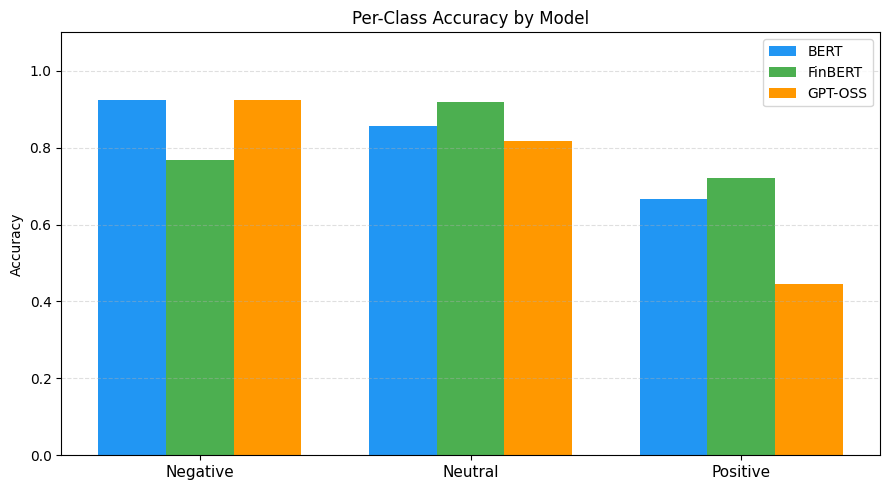

In [23]:
# ── Per-Class Accuracy Breakdown ──
per_class = []
for label in LABELS:
    mask = master_df['true_label'] == label
    subset = master_df[mask]
    if len(subset) == 0:
        continue
    per_class.append({
        'Class': label.title(),
        'Count': len(subset),
        'BERT Acc':    round(accuracy_score(subset['true_label'], subset['bert_pred']), 4),
        'FinBERT Acc': round(accuracy_score(subset['true_label'], subset['finbert_pred']), 4),
        'GPT-OSS Acc': round(accuracy_score(subset['true_label'], subset['gpt_oss_pred']), 4),
    })

per_class_df = pd.DataFrame(per_class)
print("=== Per-Class Accuracy ===")
print(per_class_df.to_string(index=False))

# Grouped bar chart for per-class accuracy
fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(per_class_df))
width = 0.25

ax.bar([i - width for i in x], per_class_df['BERT Acc'],    width, label='BERT',    color='#2196F3')
ax.bar(list(x),                 per_class_df['FinBERT Acc'], width, label='FinBERT', color='#4CAF50')
ax.bar([i + width for i in x], per_class_df['GPT-OSS Acc'], width, label='GPT-OSS', color='#FF9800')

ax.set_xticks(list(x))
ax.set_xticklabels(per_class_df['Class'], fontsize=11)
ax.set_ylabel('Accuracy')
ax.set_title('Per-Class Accuracy by Model')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Summary

| Aspect | BERT (fine-tuned) | FinBERT (fine-tuned) | GPT-OSS 20B (prompted) |
|--------|-------------------|----------------------|------------------------|
| **Training** | Fine-tuned on CN7050 | Fine-tuned on CN7050 | Zero-shot prompted |
| **Parameters** | ~110M | ~110M | ~20B |
| **Domain Knowledge** | General → financial | Financial pre-training | General knowledge |
| **Inference Speed** | Fast (local GPU) | Fast (local GPU) | Slower (API calls) |
| **Key Strength** | General adaptability | Financial domain expertise | Explainable reasoning |
| **Key Weakness** | No financial pre-training | May overfit financial patterns | Prompt-sensitive, slower |